In [487]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [488]:
import pandas as pd

df = pd.read_csv(r"C:\Users\kd940\OneDrive\Documents\yelp_dataset_reviews.csv")

In [489]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [490]:
df.tail()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
49995,49995,V_bNx4GEH8ChNNA0GPMrOA,_-x9v81zddshIEwRirV7kQ,GBTPC53ZrG1ZBY3DT8Mbcw,4,0,0,0,Came here first for breakfast and had their yu...,2016-10-29 00:54:49
49996,49996,5beIdB00qToFzllb4alZNQ,VEOTasfs8zYs7grZ4C5Xfw,EQ-TZ2eeD_E0BHuvoaeG5Q,2,0,0,0,Food was good. I had a decent breakfast but no...,2017-08-09 13:12:33
49997,49997,rjFWnq1zQTRzCyqV0jzZHw,AT_p7NkLqd50ugp3wjFg2Q,_RFqyBgklIBqOAM-zzV_WQ,3,0,1,0,It's cool that Second Image is trying. They so...,2010-07-11 21:41:35
49998,49998,8LRFPHiso_kuCseg5BJx8A,NSCNU_j0vSdeRMIme3H0rg,8agPzX-O-8LEDjDNloSdzQ,4,1,0,1,"Best shrimp on the beach! Steamed to order, d...",2017-04-09 23:23:56
49999,49999,5C6u-caMG39RkvDuAYSVew,TnLZ2QkrO9WpzDLLORvJtQ,M0c99tzIJPIbrY_RAO7KSQ,4,0,0,0,"The hotel is very nice and clean, and looks fa...",2016-08-06 02:17:10


In [491]:
df.shape

(50000, 10)

In [492]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   50000 non-null  int64
 1   review_id    50000 non-null  str  
 2   user_id      50000 non-null  str  
 3   business_id  50000 non-null  str  
 4   stars        50000 non-null  int64
 5   useful       50000 non-null  int64
 6   funny        50000 non-null  int64
 7   cool         50000 non-null  int64
 8   text         50000 non-null  str  
 9   date         50000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 34.0 MB


In [493]:
df.isna().sum()

Unnamed: 0     0
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

In [494]:
df['stars'].unique()

array([3, 5, 4, 1, 2])

In [495]:
df["sentiment"] = df["stars"].map({
    1: "Negative",
    2: "Negative",
    3: "Neutral",
    4: "Positive",
    5: "Positive"
})

In [496]:
sentiment_count=df['sentiment'].value_counts()
sentiment_count

sentiment
Positive    34941
Negative     9382
Neutral      5677
Name: count, dtype: int64

Text(0, 0.5, 'Number of Reviews')

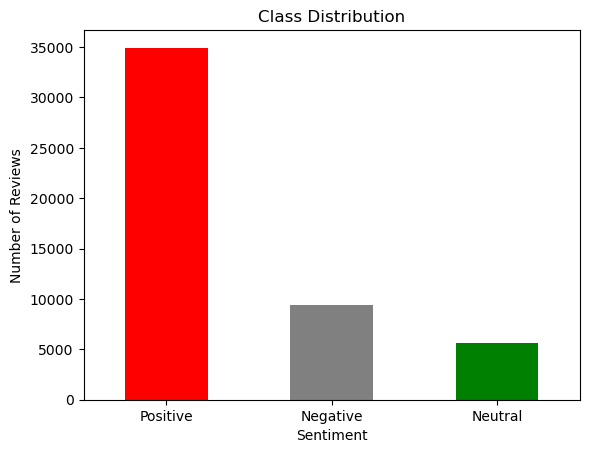

In [691]:
plt.Figure(figsize=(8,5))
sentiment_count.plot(kind='bar',color=["red","gray","green"])
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.xticks(rotation=0)
plt.ylabel("Number of Reviews")

### Interpretation: 
#### 1.Postive reviews are the majority class.
#### 2.Neutral reviews are the minority class.
#### 3.Negative reviews are the fewer.
#### 4.The dataset is imbalanced, Which explains why the Neutral Class is harder to learn for model 

The class distribution indicates that the Yelp dataset is dominated by positive reviews, followed by negative and neutral reviews. This class imbalance is common in customer review datasets because satisfied customers are more likely to leave high ratings. But during Model Devolopment we need to use resample, stratified train-test split, weighting technique because of  imbalanced class and to prevent bias result.

In [498]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date,sentiment
0,0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Neutral
1,1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Positive
2,2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Neutral
3,3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Positive
4,4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Positive


In [499]:
! pip install nltk
! pip install contractions

In [500]:
import re
import string
import contractions
import nltk

In [501]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [502]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [503]:
stop_words = set(stopwords.words('english'))
print(stop_words)
stop_words = stop_words - {"not", "no", "nor","won't","hasn't","hadn't","haven't","doesn't","didn","isn't","aren't"}
lemmatizer = WordNetLemmatizer()

{'them', 'how', 'he', 'most', 'with', 'my', 'if', "you'd", 'needn', 'herself', "i'm", 'm', 've', "i'd", 'as', "doesn't", 'few', 'himself', 'under', 'who', 'ma', "mustn't", 'weren', 'by', 'a', "couldn't", 're', "we'll", 'other', 'against', 'once', "he's", 'here', 'him', 'all', 'of', 'hers', 'hadn', 'those', 'having', 'couldn', "i've", 'do', 'over', 'don', 'being', 'ours', 'its', 'but', "haven't", "needn't", "shan't", 'which', 'you', 'yourselves', 'shan', "wouldn't", 'such', 'through', 'why', 'are', "that'll", 'off', 'they', 'there', 'doesn', 'ain', 'did', 'more', 'while', 'same', 'each', 'our', 'no', 'out', 'some', 's', 'from', 'hasn', "he'll", 'didn', 'down', 'on', 'because', "shouldn't", 'aren', 'were', 'mustn', "isn't", 'at', "it's", 'just', 'these', 'haven', 'she', 'was', 'this', 'too', 'so', 'above', 'ourselves', 'any', 'should', "it'd", 'than', 'i', 'be', 'can', 'am', 'whom', "won't", 'me', 'what', 'y', "i'll", 'your', "she'll", 'nor', "we've", 'up', "she's", 'between', 'both', 't

In [504]:
def preprocess_text(text):
    text = text.lower()
    text=contractions.fix(text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if len(word)>2]
    tokens = [word for word in tokens if not re.fullmatch(r'(.)\1{2,}', word)]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

In [505]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [506]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date,sentiment,clean_text
0,0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Neutral,decide eat aware going take hour beginning end...
1,1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Positive,taken lot spin class year nothing compare clas...
2,2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Neutral,family diner buffet eclectic assortment large ...
3,3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Positive,wow yummy different delicious favorite lamb cu...
4,4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Positive,cute interior owner gave tour upcoming patioro...


In [507]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.8,
    max_features=20000,
    ngram_range=(1,2),
    token_pattern=r"\b[a-zA-Z]{3,}\b"
)

In [509]:
x=tfidf.fit_transform(df['clean_text'])

In [510]:
y=df['sentiment']

In [511]:
x.shape

(50000, 20000)

In [512]:
print(tfidf.get_feature_names_out()[:500])

['aaron' 'abandoned' 'abc' 'ability' 'abita' 'able' 'able accommodate'
 'able come' 'able eat' 'able enjoy' 'able finish' 'able fit' 'able make'
 'able order' 'able seat' 'able sit' 'able table' 'able taste' 'able try'
 'able use' 'able walk' 'absent' 'absinthe' 'absolute' 'absolute best'
 'absolute favorite' 'absolute worst' 'absolutely' 'absolutely amazing'
 'absolutely awesome' 'absolutely beautiful' 'absolutely best'
 'absolutely delicious' 'absolutely disgusting' 'absolutely fabulous'
 'absolutely fantastic' 'absolutely gorgeous' 'absolutely horrible'
 'absolutely incredible' 'absolutely love' 'absolutely loved'
 'absolutely perfect' 'absolutely recommend' 'absolutely ridiculous'
 'absolutely terrible' 'absolutely wonderful' 'absolutely worth'
 'absorbed' 'absurd' 'abundance' 'abundant' 'abv' 'abysmal' 'acai'
 'acai bowl' 'accent' 'accept' 'accept credit' 'acceptable' 'accepted'
 'accepts' 'access' 'accessible' 'accessory' 'accident' 'accidentally'
 'accommodate' 'accommodate larg

In [513]:
sample = pd.DataFrame(
    x[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)
sample.head(10)

,aaron,abandoned,abc,ability,abita,able,able accommodate,able come,able eat,able enjoy,...,zest,zesty,ziggy,ziggy burger,zimmer,zombie,zone,zoo,zoodles,zucchini
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [612]:
df[df["clean_text"].str.contains(r"\baaa\b", na=False)].shape

(2, 12)

In [613]:
from sklearn.model_selection import train_test_split

In [614]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# Linear Support Vector Classifier

In [615]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.01, 0.1, 1, 5, 10]
}

grid = GridSearchCV(
    estimator=LinearSVC(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid.fit(x_train,y_train)

,estimator,LinearSVC(cla...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [616]:
print("Best C:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best C: {'C': 0.1}
Best CV Score: 0.6945633305621629


In [617]:
best_svm = grid.best_estimator_

In [618]:
y_pred = best_svm.predict(x_test)

In [619]:
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,f1_score

In [620]:
svm_cm=confusion_matrix(y_test,y_pred)
svm_cm

array([[1511,  184,  182],
       [ 278,  413,  444],
       [ 165,  324, 6499]])

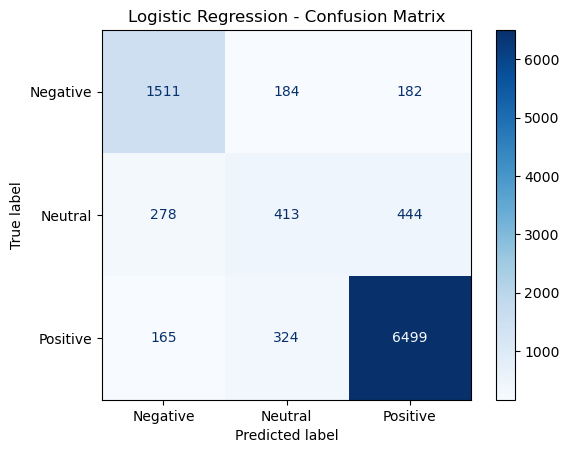

In [621]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_svm,x_test,y_test,cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [654]:
svm_accuracy=accuracy_score(y_test,y_pred)
print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8451


In [655]:
svm_pre=precision_score(y_test,y_pred,average='macro')
print(f"svm precision: {svm_pre:.4f}")

svm precision: 0.7303


In [656]:
svm_rec=recall_score(y_test,y_pred,average='macro')
print(f"svm recall: {svm_rec:.2f}")

svm recall: 0.64


In [657]:
svm_f1_score=f1_score(y_test,y_pred,average='macro')
print(f"SVM f1_score: {svm_f1_score:.4f}")

SVM f1_score: 0.6600


In [658]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.81      0.77      0.79      1877
     Neutral       0.51      0.18      0.27      1135
    Positive       0.87      0.97      0.92      6988

    accuracy                           0.85     10000
   macro avg       0.73      0.64      0.66     10000
weighted avg       0.82      0.85      0.82     10000



# Logistic Regression

In [659]:
from sklearn.linear_model import LogisticRegression

In [660]:
lr_model = LogisticRegression(max_iter=1000,random_state=42)

In [661]:
lr_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [662]:
y_pred = lr_model.predict(x_test)

In [663]:
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,f1_score

In [664]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1451,   97,  329],
       [ 242,  208,  685],
       [  91,  105, 6792]])

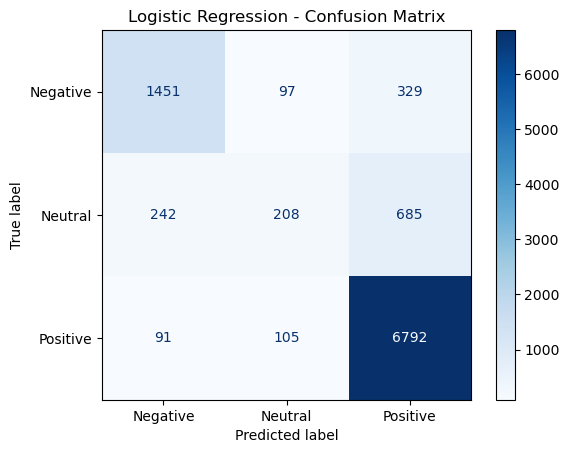

In [665]:

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(lr_model,x_test,y_test,cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [666]:
LR_Accuracy=accuracy_score(y_test,y_pred)
print(f"Logistic Regression Accuracy: {LR_Accuracy:.4f}")

Logistic Regression Accuracy: 0.8451


In [667]:
LR_pre=precision_score(y_test,y_pred,average='macro')
print(f"Logistic Regression Precision: {LR_pre:.4f}")

Logistic Regression Precision: 0.7303


In [668]:
LR_rec=recall_score(y_test,y_pred,average='macro')
print(f"Logistic Regression Recall: {LR_rec:.4f}")

Logistic Regression Recall: 0.6428


In [669]:
LR_f1_score=f1_score(y_test,y_pred,average='macro')
print(f"Logistic Regression f1_score: {LR_f1_score:.4f}")

Logistic Regression f1_score: 0.6600


In [670]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.81      0.77      0.79      1877
     Neutral       0.51      0.18      0.27      1135
    Positive       0.87      0.97      0.92      6988

    accuracy                           0.85     10000
   macro avg       0.73      0.64      0.66     10000
weighted avg       0.82      0.85      0.82     10000



# Multinomial Naive Bayes

In [671]:
from sklearn.naive_bayes import MultinomialNB

In [672]:
nb_model=MultinomialNB(alpha=1.0)

In [673]:
nb_model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [674]:
nb_y_pred=nb_model.predict(x_test)

In [675]:
nb_cm=confusion_matrix(y_test,nb_y_pred)
nb_cm

array([[1176,    1,  700],
       [ 175,    3,  957],
       [  88,    0, 6900]])

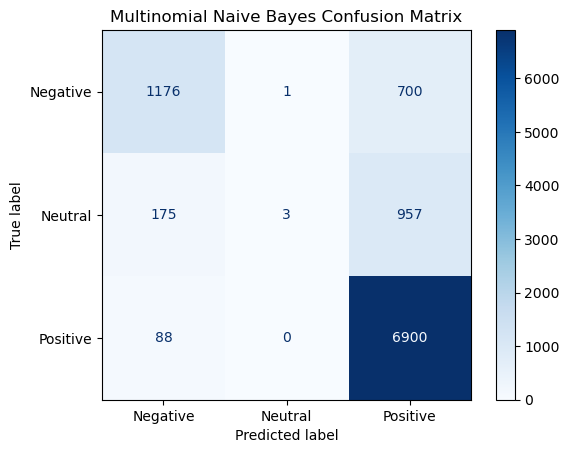

In [676]:
ConfusionMatrixDisplay.from_estimator(nb_model,x_test,y_test,cmap="Blues")
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

In [677]:
nb_accuracy=accuracy_score(y_test,nb_y_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Naive Bayes Accuracy: 0.8079


In [678]:
nb_pre=precision_score(y_test,nb_y_pred,average='macro')
print(f"Naive Bayes Precision: {nb_pre:.4f}")

Naive Bayes Precision: 0.7912


In [679]:
nb_rec=recall_score(y_test,nb_y_pred,average='macro')
print(f"Naive Bayes Recall: {nb_rec:.4f}")

Naive Bayes Recall: 0.5389


In [686]:
nb_f1_score=f1_score(y_test,nb_y_pred,average='macro')
print(f"Naive Bayes f1_score: {nb_f1_score:.4f}")

Naive Bayes f1_score: 0.5341


In [687]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.81      0.77      0.79      1877
     Neutral       0.51      0.18      0.27      1135
    Positive       0.87      0.97      0.92      6988

    accuracy                           0.85     10000
   macro avg       0.73      0.64      0.66     10000
weighted avg       0.82      0.85      0.82     10000



In [688]:
Evaluation_of_Models=pd.DataFrame({

    "Model":['Logistic Regression','Multinomial Naive Bayes','Linear SVM'],
    "Accuracy":[LR_Accuracy,nb_accuracy,svm_accuracy],
    "Precision_Score":[LR_pre,nb_pre,svm_pre],
    "Recall_Score":[LR_rec,nb_rec,svm_rec],
    "f1_score":[LR_f1_score,nb_f1_score,svm_f1_score]
})
Evaluation_of_Models

,Model,Accuracy,Precision_Score,Recall_Score,f1_score
0,Logistic Regression,0.8451,0.730253,0.642751,0.660048
1,Multinomial Naive Bayes,0.8079,0.791197,0.538861,0.534100
2,Linear SVM,0.8451,0.730253,0.642751,0.660048


Text(0, 0.5, 'Number of Reviews')

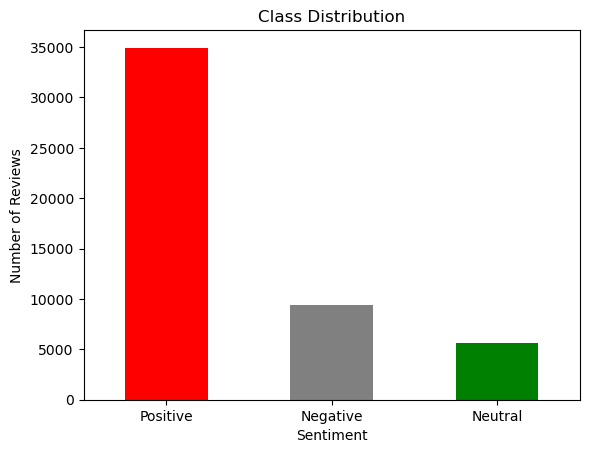

In [704]:
plt.Figure(figsize=(8,5))
sentiment_count.plot(kind='bar',color=["red","gray","green"])
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.xticks(rotation=0)
plt.ylabel("Number of Reviews")

### Interpretation: 
#### 1.Postive reviews are the majority class.
#### 2.Neutral reviews are the minority class.
#### 3.Negative reviews are the fewer.
#### 4.The dataset is imbalanced, Which explains why the Neutral Class is harder to learn for model 

In [705]:
!pip install wordcloud

In [708]:
from wordcloud import WordCloud

In [715]:
from wordcloud import STOPWORDS

custom_stopwords = STOPWORDS.union({
    "food",
    "restaurant",
    "place",
    "one",
    "go",
    "get",
    "would",
    "could",
    "really"
})

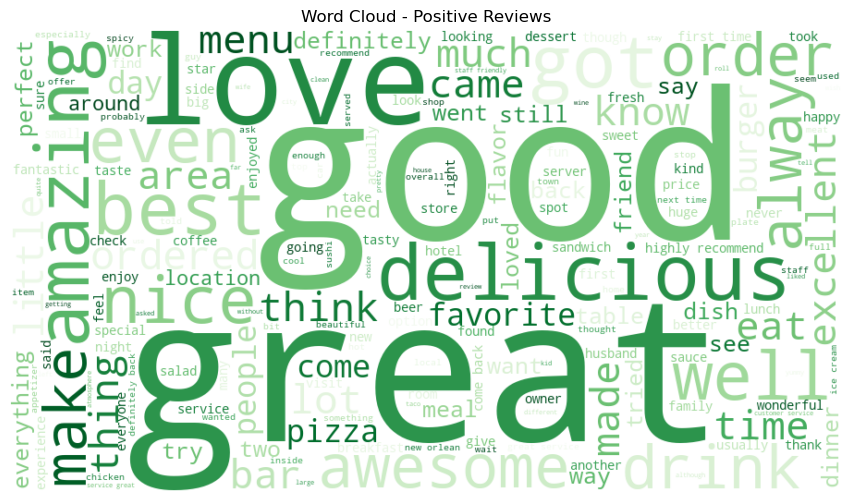

In [716]:
positive_text = " ".join(
    df[df["sentiment"]=="Positive"]["clean_text"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

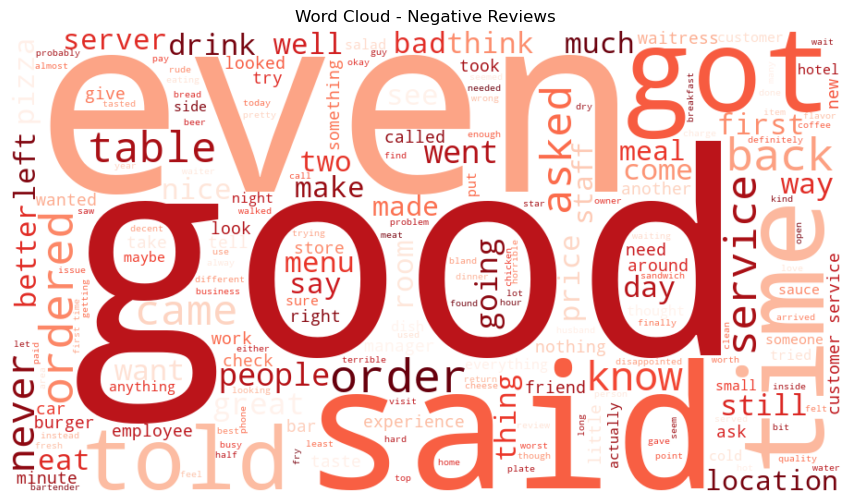

In [717]:
negative_text = " ".join(
    df[df["sentiment"]=="Negative"]["clean_text"]
)
wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Reds"
).generate(negative_text)


plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

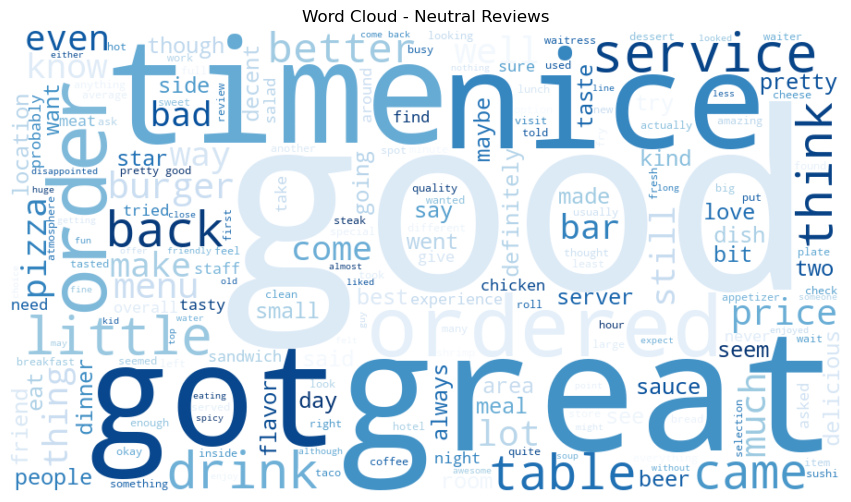

In [719]:
neutral_text = " ".join(
    df[df["sentiment"]=="Neutral"]["clean_text"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Blues"
).generate(neutral_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Neutral Reviews")
plt.show()